In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [3]:
virulence_matches = pd.read_csv("../data/paeruginosa/summary_gene.tsv", sep="\t")

In [4]:
virulence_matches = virulence_matches[~virulence_matches.astype(str).apply(lambda x: x.str.contains(r'\.txt', na=False)).any(axis=1)]

In [5]:
virulence_matches.rename(columns={"Unnamed: 0":"Isolate"}, inplace=True)

In [6]:
virulence_matches = virulence_matches.drop(columns=["Unnamed: 1"])

In [7]:
virulence_matches.reset_index(inplace=True)

In [8]:
virulence_matches.drop(columns="index", inplace=True)

In [9]:
virulence_matches

,Isolate,exoT,phzH,tagR1,tagS1,tagT1,ppkA,pppA,tagF1,icmF1,...,algR,fimS,cyaA,pauC,algC,sphC,spoT,oxyR,wbpX,tonB1
0,SRR17226513,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,SRR17143812,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,SH040221x2x75,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,F1S1R2D1B1P2B07,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,F1S1R2D4B3P3A02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8211,F1S1R1D1B3P1E03,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8212,SH216x41,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8213,F1S1R1D2B1P1F12,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8214,F1S1R2D2B1P1B06,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [10]:
def plot_vir_category_frequency(df):
    """
    Plots the frequency of resistance presence by AMR category as a bar plot,
    excluding genes present in all strains.
    
    Parameters:
    df_subset (pd.DataFrame): Subset of binary gene presence/absence data.
    """
    genes_only = df.drop(columns=["Isolate"])
    variable_genes = genes_only.loc[:, genes_only.sum() < 8100]
    gene_frequencies = variable_genes.sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(30, 9))

    sns.barplot(
        x=gene_frequencies.index,
        y=gene_frequencies.values,
        ax=ax,
        color='xkcd:salmon',
        alpha=0.6
    )

    ax.set_xlabel("Virulence Gene", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.set_xticks(range(len(gene_frequencies.index)))
    ax.set_xticklabels(gene_frequencies.index, rotation=45, ha="right")
    ax.legend(["Frequency"], facecolor="white")
    ax.set_title("P. aeruginosa Virulence Gene Frequency (Excludes Core Genes)", fontsize=16)

    plt.tight_layout()
    plt.savefig("../out/vir_paeruginosa_filtered.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_paeruginosa_filtered.png", format="png", dpi=150)
    plt.show();

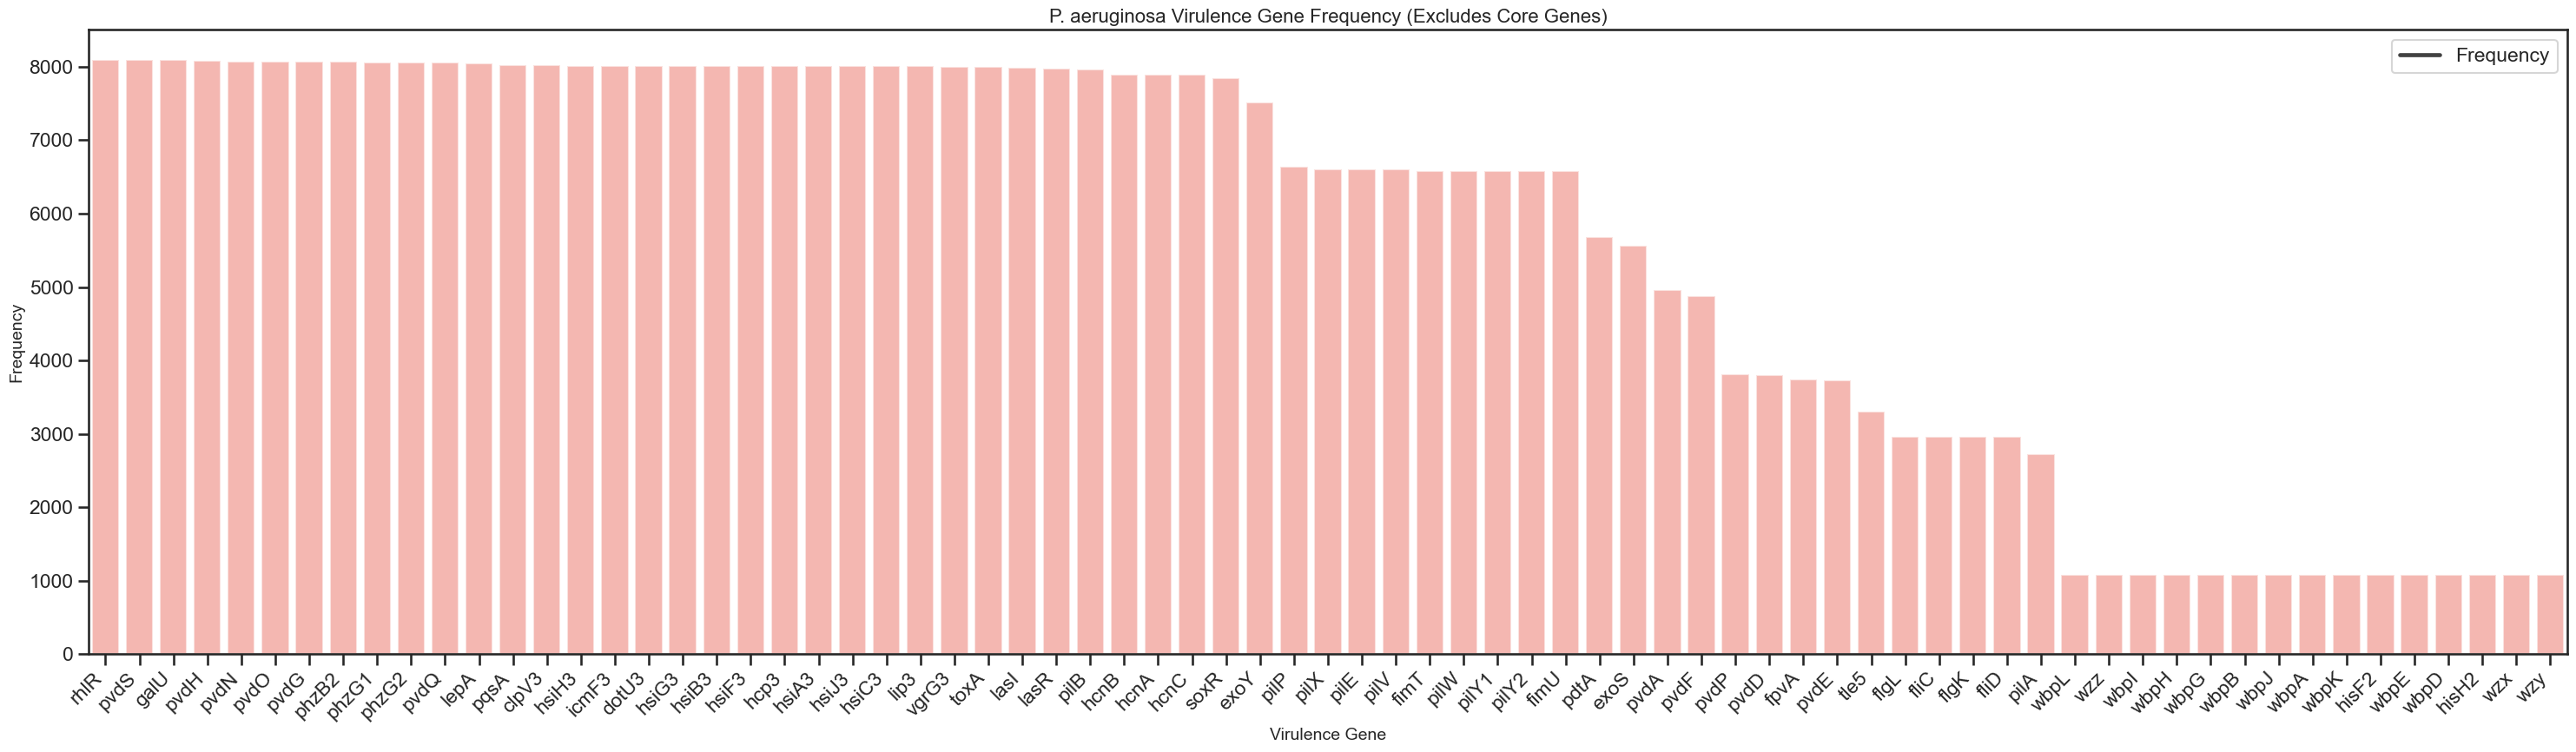

In [11]:
plot_vir_category_frequency(virulence_matches)

In [12]:
def avirulence_score_pa(df):
    """
    Compute avirulence score for Pseudomonas aeruginosa based on updated hierarchy:
    5 = all genes present
    4 = missing only pvd OR fpvA OR tle5 genes
    3 = missing pil/fim genes 
    2 = missing pvd OR fpvA OR tle5 genes AND pil/fim
    1 = missing pvd OR fpvA OR tle5 gene AND pil/fim AND exoY or exoS
    0 = missing all genes above independent of others
    """
    # Define gene groups
    pvd_genes = {'pvdA', 'pvdF', 'pvdE', 'pvdD', 'fpvA'}
    pil_genes = {gene for gene in df.columns if gene.startswith('pil')}
    fim_genes = {gene for gene in df.columns if gene.startswith('fim')}
    exo_genes = {'exoS', 'exoY'}
    tle5 = {"tle5"}

    # Ensure genes exist in the DataFrame
    pvd_genes = {g for g in pvd_genes if g in df.columns}
    pil_genes = {g for g in pil_genes if g in df.columns}
    fim_genes = {g for g in fim_genes if g in df.columns}
    exo_genes = {g for g in exo_genes if g in df.columns}

    def score_row(row):
        has_pvd = any(row[g] == 1 for g in pvd_genes)
        has_pil = any(row[g] == 1 for g in pil_genes)
        has_fim = any(row[g] == 1 for g in fim_genes)
        has_exo = any(row[g] == 1 for g in exo_genes)
        has_tle5 = any(row[g] == 1 for g in tle5)


        # Logic based on presence/absence combinations
        if has_pvd and has_pil and has_fim and has_exo and has_tle5:
            return 5
        elif has_pvd and not has_tle5 and (has_pil or has_fim) and has_exo:
            return 4
        elif not has_pvd and not has_tle5 and has_exo and (has_pil or has_fim):
            return 3
        elif has_exo:
            return 2
        elif not has_exo:
            return 1
        else:
            return 0

    result = df[['Isolate']].copy()
    result['score'] = df.apply(score_row, axis=1)
    return result

In [13]:
score = avirulence_score_pa(virulence_matches)

In [14]:
score_binary = score['score'].astype(pd.CategoricalDtype(categories=[0, 1, 2, 3, 4, 5]))
score_binary = pd.get_dummies(score_binary, prefix="score")
score_binary.index = score.index

In [15]:
def plot_virulencescore_frequency(df_binary):
    """
    Plots the frequency of virulence factor presence by category as a bar plot.

    Parameters:
    df_binary (pd.DataFrame): Binary VF DataFrame with 0s and 1s (Isolates x Categories).
    """
    ordered_cols = [f"score_{i}" for i in range(6) if f"score_{i}" in df_binary.columns]
    vir_frequencies = df_binary[ordered_cols].sum()

    if len(df_binary) <= 10:
        print(f"Not enough isolates to plot: {len(df_binary)} (≤10). Skipping plot.")
        return

    if (vir_frequencies < 10).all():
        print("No virulence scores with frequency ≥10. Skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        x=vir_frequencies.index,
        y=vir_frequencies.values,
        order=ordered_cols,
        color='xkcd:salmon',
        alpha=0.6,
        ax=ax
    )

    ax.set_xlabel("Virulence Score")
    ax.set_ylabel("Frequency")
    ax.set_title("P. aeruginosa")
    ax.set_facecolor("white")
    ax.tick_params(axis='x', rotation=45)

    sns.despine()
    plt.tight_layout()
    plt.savefig("../out/vir_score_paeruginosa.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_score_paerugnisa.png", format="png", dpi=150)
    plt.show()

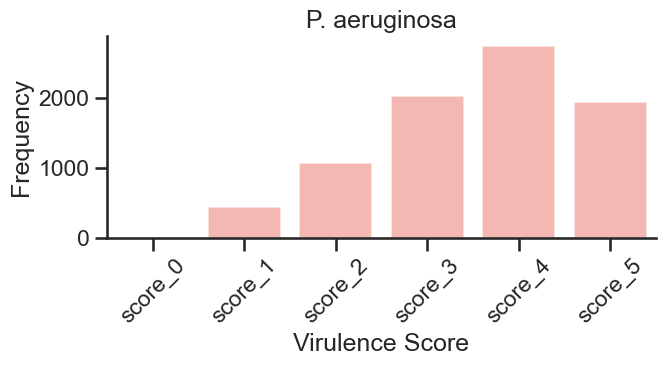

In [16]:
plot_virulencescore_frequency(score_binary)